# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

In [47]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly as px

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn import set_config
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score




#Creating a dataframe from the csv
df = pd.read_csv("data/vehicles.csv")

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [48]:
#Beginning the Exploratory Data Analysis of the dataset

df.head() # Taking a peak at the data

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


Looking at the first 5 rows of this dataset, it is apparent that there are multiple columns with NaN values. This will need be cleaned up before conducting analysis

In [49]:
#Printing Number of Rows and Columns plus Column Names
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f"Column Names: {df.columns.tolist()}")

Rows: 426880, Columns: 18
Column Names: ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']


This dataset contains 426,880 car records and 18 different features. This is an indication of a large dataset and could be suitable for regression modeling.

In [50]:
#Printing the Datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

This dataset contains numerical and categorical attributes. It also contains several NaN values mostly in the categorical fields such as cylinders, size and condition. The missing values will be cleaned up during the next phase

In [51]:
print("====================================")
print("Columns with Null Values")
print("====================================")
print(df.isnull().sum().sort_values(ascending=False))
print("\n====================================")
print("Columns with Null Values - Percentages")
print("====================================")
((df.isnull().sum() / len(df) * 100).map("{:.2f}%".format)).sort_values(ascending=False)

Columns with Null Values
size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
region               0
id                   0
price                0
state                0
dtype: int64

Columns with Null Values - Percentages


,0
size,71.77%
cylinders,41.62%
condition,40.79%
manufacturer,4.13%
VIN,37.73%
drive,30.59%
paint_color,30.50%
type,21.75%
title_status,1.93%
model,1.24%


My intial look into the dataset revealed several NaN entries. This command is showing the extent of the null values and the percentage of null values.

In [52]:
#Looking at the unique values for the cylinder column
df['cylinders'].value_counts(dropna=False)

,count
cylinders,
NaN,177678
6 cylinders,94169
4 cylinders,77642
8 cylinders,72062
5 cylinders,1712
10 cylinders,1455
other,1298
3 cylinders,655
12 cylinders,209


In [53]:
display(df['cylinders'].value_counts(dropna=True))

,count
cylinders,
6 cylinders,94169
4 cylinders,77642
8 cylinders,72062
5 cylinders,1712
10 cylinders,1455
other,1298
3 cylinders,655
12 cylinders,209


In [54]:
#Looking at the unique values for the condition column
df['condition'].value_counts(dropna=False)

,count
condition,
NaN,174104
good,121456
excellent,101467
like new,21178
fair,6769
new,1305
salvage,601


In [55]:
#Looking at the unique values for the drive column
df['drive'].value_counts(dropna=False)

,count
drive,
4wd,131904
NaN,130567
fwd,105517
rwd,58892


In [56]:
#Looking at the unique values for the paint_color column
df['paint_color'].value_counts(dropna=False)

,count
paint_color,
NaN,130203
white,79285
black,62861
silver,42970
blue,31223
red,30473
grey,24416
green,7343
custom,6700


Replace missing values with unknown

In [57]:
df['price'].describe()

,price
count,4.268800e+05
mean,7.519903e+04
std,1.218228e+07
min,0.000000e+00
25%,5.900000e+03
50%,1.395000e+04
75%,2.648575e+04
max,3.736929e+09


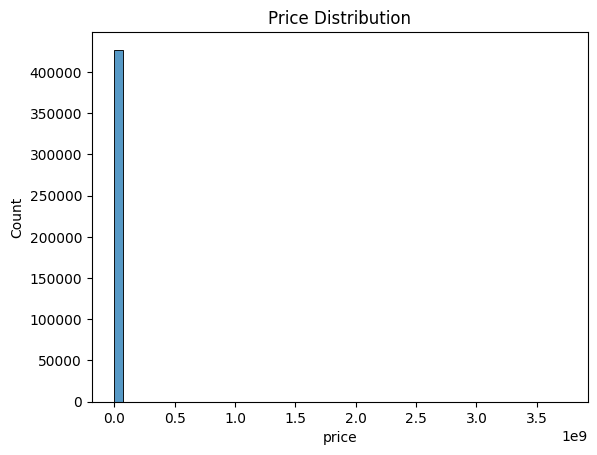

In [58]:
sns.histplot(df['price'], bins=50)
plt.title('Price Distribution')
plt.show()

In [59]:
df['price'].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,price
0.05,0.00
0.25,5900.00
0.50,13950.00
0.75,26485.75
0.95,44500.00


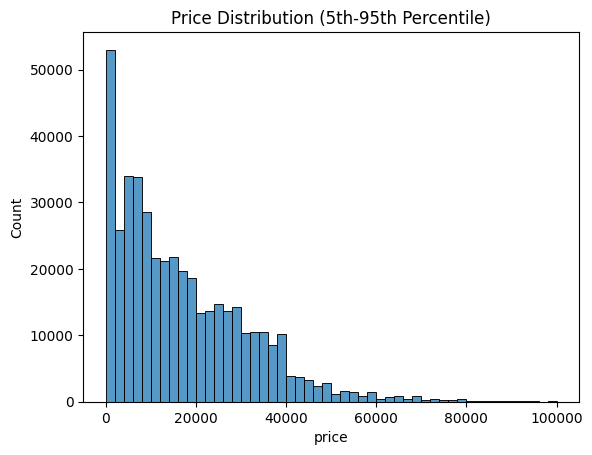

In [60]:
lower = df['price'].quantile(0.05)
upper = df['price'].quantile(0.95)

df_temp = df[(df['price'] > lower) & (df['price'] < upper)]

sns.histplot(df[df['price'] < 100000]['price'], bins=50)
plt.title('Price Distribution (5th-95th Percentile)')
plt.show()

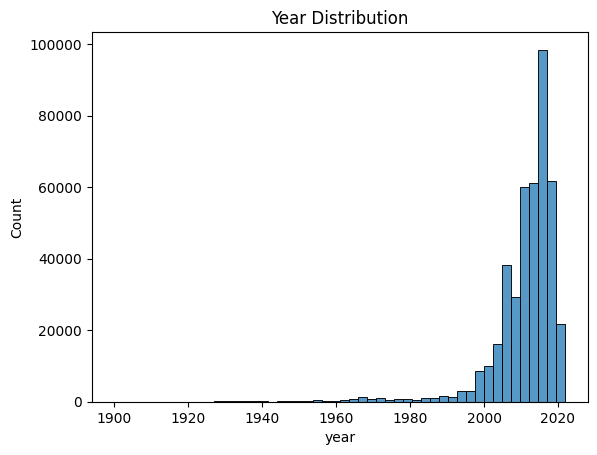

In [61]:
sns.histplot(df['year'].dropna(), bins=50)
plt.title('Year Distribution')
plt.show()

This chart illustrates that the distribution of most vehicles are from 2000-2020 with very few being older than 2000. This suggest that the dataset contains mostly recent vehicles.

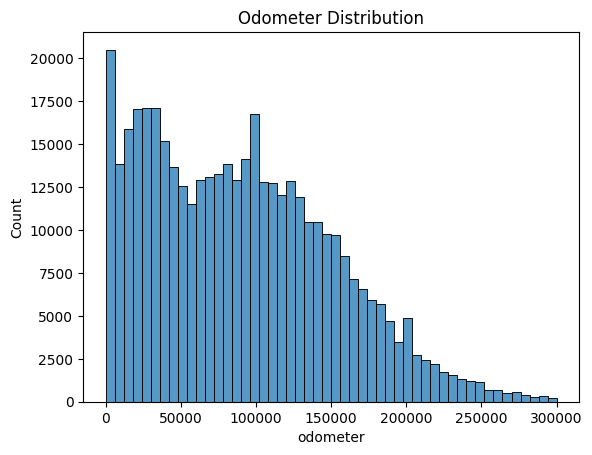

In [62]:
sns.histplot(df[df['odometer'] < 300000]['odometer'], bins=50)
plt.title('Odometer Distribution')
plt.show()

The odometer distribution is slightly skewed to the right. The milage for most vehicles are between 20,000 and 150,000. Vehicles with 300,000 miles and above were excluded to improve chart visualization

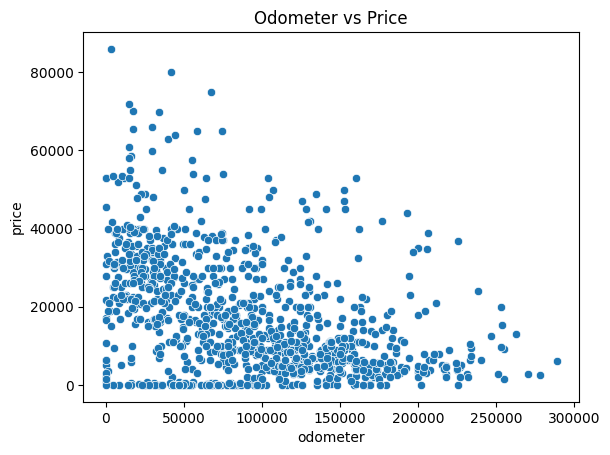

In [63]:
df_filtered = df[(df['odometer'] < 300000) & (df['price'] < 100000)]

df_sample = df_filtered.sample(n=1000, random_state=42)

sns.scatterplot(data=df_sample, x='odometer', y='price')
plt.title('Odometer vs Price')
plt.show()

Initial scatterplot was too crowded due to overplotting which made it difficult to interpret the data. I took a random sample of the data to improve the visualization. The plot shows a downward trend where the higher the milage, the lower the price of the vehicle. This suggests that the odometer reading plays a part in the price of the vehicle.

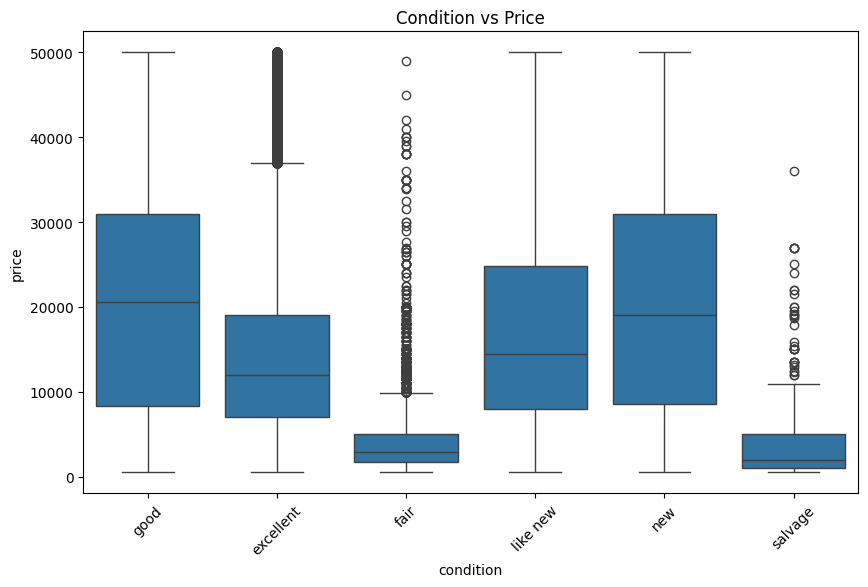

In [64]:
df_price = df[(df['price'] > 500) & (df['price'] < 50000)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='condition', y='price', data=df_price)
plt.xticks(rotation=45)
plt.title('Condition vs Price')
plt.show()

This boxplot shows the distribution of vehicle prices across various condition categories. Vehicles in better condition tended to have higher listed prices in comparison to vehicles in poor condition. This suggests that the condition of the vehicle is an important attribute in determining the price of the vehicle.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [65]:
df = df.drop(columns=['region', 'id', 'VIN', 'size'])

Dropping the 'id' and 'VIN' columns because they are unique values and do not provide any benefit to the analysis. Dropping the 'region' column because it is redundant info thats captured in the state column. Dropping the 'size' column because it contains 70% null values.

In [66]:
#Remove price outliers
lower = df['price'].quantile(0.01)
upper = df['price'].quantile(0.99)

df = df[(df['price'] > lower) & (df['price'] < upper)]

In [67]:
upper_odometer = df['odometer'].quantile(0.99)

df = df[df['odometer'] < upper_odometer]

In [68]:

df.columns.tolist()

['price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'drive',
 'type',
 'paint_color',
 'state']

In [69]:
df['cylinders'].unique()

array(['8 cylinders', '6 cylinders', nan, '4 cylinders', '5 cylinders',
       'other', '3 cylinders', '10 cylinders', '12 cylinders'],
      dtype=object)

In [70]:
#Extracting the Numberical Cylinder value and converting it to a float
df['cylinders'] = df['cylinders'].astype(str).str.extract(r'(\d+)').astype(float)

#Replacing the NaN values with the median
df['cylinders'] = df['cylinders'].fillna(df['cylinders'].median())
print(df['cylinders'].unique())
print(df['cylinders'].dtypes)

[ 8.  6.  4.  5.  3. 10. 12.]
float64


In [71]:
#Showing the number count of each cylinder value
display(df['cylinders'].value_counts(dropna=False))

,count
cylinders,
6.0,243619
4.0,72293
8.0,63912
5.0,1633
10.0,1289
3.0,601
12.0,146


Cleaned the 'cylinders' column by extracting all of the text and converting the remaining values to numerical data. The value count confirms all rows in the 'cylinder' column have been cleaned and are ready for analysis.

In [72]:
df['condition'] = df['condition'].fillna('unknown')
print(f"Number of NaN Values: {df['condition'].isnull().sum()}")
print()
print(df['condition'].value_counts())

Number of NaN Values: 0

condition
unknown      146306
good         117430
excellent     92340
like new      19617
fair           6222
new            1028
salvage         550
Name: count, dtype: int64


In [73]:
df['drive'] = df['drive'].fillna('unknown')
print(df['drive'].isnull().sum())
print(df['drive'].value_counts())

0
drive
unknown    117216
4wd        116379
fwd         96558
rwd         53340
Name: count, dtype: int64


In [74]:
df['paint_color'] = df['paint_color'].fillna('unknown')
print(f'Number of NaN Values: {df['paint_color'].isnull().sum()}')
print()
print(df['paint_color'].value_counts())

Number of NaN Values: 0

paint_color
unknown    113329
white       70607
black       57106
silver      39474
blue        28870
red         28131
grey        22307
green        6872
custom       6291
brown        6096
yellow       1958
orange       1808
purple        644
Name: count, dtype: int64


In [75]:
df.isnull().sum()

,0
price,0
year,994
manufacturer,14702
model,4251
condition,0
cylinders,0
fuel,2292
odometer,0
title_status,7349
transmission,1485


In [76]:
#Writing a for loop to fill all missing (NaN) values from designated columns with 'unknown'
for col in ['manufacturer', 'fuel', 'model', 'title_status', 'transmission', 'type']:
    df[col] = df[col].fillna('unknown')
    print(f'Number of NaN Values for {col}: {df[col].isnull().sum()}')
    print()

Number of NaN Values for manufacturer: 0

Number of NaN Values for fuel: 0

Number of NaN Values for model: 0

Number of NaN Values for title_status: 0

Number of NaN Values for transmission: 0

Number of NaN Values for type: 0



In [77]:
#Dropping rows with a missing year
df = df.dropna(subset=['year'])

In [78]:
#Validating that all NaN values have been taken care of
df.isnull().sum()

,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0
transmission,0


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [79]:
X = df.drop(columns=['price'])
y = df['price']

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [81]:
numberic_features = ['year', 'odometer', 'cylinders']
categorical_features = ['manufacturer', 'model', 'condition', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']



In [82]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numberic_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [83]:
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
lr_model.fit(X_train, y_train)
lr_model.score(X_test, y_test)

0.7322510038354964

In [84]:
ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
ridge_model.fit(X_train, y_train)
ridge_model.score(X_test, y_test)

0.7355450852966444

In [85]:
#rf_model = Pipeline([
#   ('preprocessor', preprocessor),
#   ('model', RandomForestRegressor(n_estimators = 4, random_state = 42))
#])
#rf_model.fit(X_train, y_train)
#rf_model.score(X_test, y_test)

Explored using a random forest regressor but due to computational limitations with the environment, the model wasnt fully evaluated.

In [86]:
lr_cv = cross_val_score(lr_model, X_train, y_train, cv=3)
print(f'Linear Regression CV Score: {lr_cv.mean()}')

Linear Regression CV Score: 0.7209369225645422


In [87]:
ridge_cv = cross_val_score(ridge_model, X_train, y_train, cv=3)
print(f'Ridge Regression CV Score: {ridge_cv.mean()}')

Ridge Regression CV Score: 0.7265766831194166


In [88]:
#rf_cv = cross_val_score(rf_model, X_train, y_train, cv=5)
#print(f'Cross Validation Scores: {rf_cv.mean()}')

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [89]:
lr_pred = lr_model.predict(X_test)
lr_r2 = lr_model.score(X_test, y_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f'LR R2: {lr_r2}')
print(f'LR RMSE: {lr_rmse}')

LR R2: 0.7322510038354964
LR RMSE: 6932.223978365396


In [90]:
ridge_pred = ridge_model.predict(X_test)
ridge_r2 = ridge_model.score(X_test, y_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
print(f'Ridge R2: {ridge_r2}')
print(f'Ridge RMSE: {ridge_rmse}')

Ridge R2: 0.7355450852966444
Ridge RMSE: 6889.448877078997


In [91]:
#rf_pred = rf_model.predict(X_test)
#rf_r2 = rf_model.score(X_test, y_test)
#rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

In [92]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'R2': [lr_r2, ridge_r2],
    'RMSE': [lr_rmse, ridge_rmse]
})
results

,Model,R2,RMSE
0,Linear Regression,0.732251,6932.223978
1,Ridge Regression,0.735545,6889.448877


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

This model can be used by a dealership to estimate the value of used cars but keeping in mind that  market demand can also influence the price. Future improvements to the model can include analyzing whether location influences vehicle prices.


